In [ ]:
!pip install mediapipe==0.10.33 opencv-python-headless numpy




In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab.patches import cv2_imshow

# Set up Face Landmarker (new MediaPipe API)
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    min_face_detection_confidence=0.5
)
detector = vision.FaceLandmarker.create_from_options(options)

# Eye landmark indices (same as before)
LEFT_EYE  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33,  160, 158, 133, 153, 144]

# EAR formula (unchanged)
def eye_aspect_ratio(landmarks, eye_indices, w, h):
    pts = [(landmarks[i].x * w, landmarks[i].y * h)
           for i in eye_indices]
    A = np.linalg.norm(np.array(pts[1]) - np.array(pts[5]))
    B = np.linalg.norm(np.array(pts[2]) - np.array(pts[4]))
    C = np.linalg.norm(np.array(pts[0]) - np.array(pts[3]))
    return (A + B) / (2.0 * C)

print("Setup complete!")

Setup complete!


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
import urllib.request

url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
urllib.request.urlretrieve(url, "/content/face_landmarker.task")
print("Done!")

import os
print(os.listdir('/content'))


Done!
['.config', 'face_landmarker.task', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving VID_20260422_090024.mp4 to VID_20260422_090024.mp4
Uploaded: ['VID_20260422_090024.mp4']


In [ ]:
EAR_THRESHOLD = 0.22
CLOSED_FRAMES = 15
frame_count = 0

cap = cv2.VideoCapture('/content/VID_20260422_090024.mp4')
frame_num = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    h, w = frame.shape[:2]

    # Convert to RGB (MediaPipe expects RGB, OpenCV gives BGR)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    result = detector.detect(mp_image)

    drowsy = False

    if result.face_landmarks:
        lm = result.face_landmarks[0]

        left_ear  = eye_aspect_ratio(lm, LEFT_EYE,  w, h)
        right_ear = eye_aspect_ratio(lm, RIGHT_EYE, w, h)
        avg_ear   = (left_ear + right_ear) / 2.0

        if avg_ear < EAR_THRESHOLD:
            frame_count += 1
            if frame_count >= CLOSED_FRAMES:
                drowsy = True
        else:
            frame_count = 0

        # Print status every 30 frames (once per second roughly)
        if frame_num % 30 == 0:
            status = "DROWSY" if drowsy else "OK"
            print(f"Frame {frame_num} | EAR: {avg_ear:.3f} | Status: {status}")

cap.release()
print("Done!")

Frame 30 | EAR: 0.330 | Status: OK
Frame 60 | EAR: 0.333 | Status: OK
Frame 90 | EAR: 0.346 | Status: OK
Frame 120 | EAR: 0.332 | Status: OK
Frame 150 | EAR: 0.333 | Status: OK
Frame 180 | EAR: 0.337 | Status: OK
Frame 210 | EAR: 0.272 | Status: OK
Frame 240 | EAR: 0.075 | Status: DROWSY
Frame 270 | EAR: 0.067 | Status: DROWSY
Frame 300 | EAR: 0.104 | Status: DROWSY
Frame 330 | EAR: 0.170 | Status: DROWSY
Frame 360 | EAR: 0.122 | Status: DROWSY
Frame 390 | EAR: 0.104 | Status: DROWSY
Frame 420 | EAR: 0.263 | Status: OK
Frame 450 | EAR: 0.320 | Status: OK
Frame 480 | EAR: 0.335 | Status: OK
Frame 510 | EAR: 0.333 | Status: OK
Frame 540 | EAR: 0.330 | Status: OK
Done!


In [ ]:
EAR_THRESHOLD = 0.22
CLOSED_FRAMES = 15
frame_count = 0

cap = cv2.VideoCapture('/content/VID_20260422_090024.mp4')

# Get video properties
fps    = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Set up output video writer
out = cv2.VideoWriter(
    '/content/drowsiness_output.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps, (width, height)
)

frame_num = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    h, w = frame.shape[:2]

    rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result   = detector.detect(mp_image)

    drowsy = False

    if result.face_landmarks:
        lm = result.face_landmarks[0]

        left_ear  = eye_aspect_ratio(lm, LEFT_EYE,  w, h)
        right_ear = eye_aspect_ratio(lm, RIGHT_EYE, w, h)
        avg_ear   = (left_ear + right_ear) / 2.0

        if avg_ear < EAR_THRESHOLD:
            frame_count += 1
            if frame_count >= CLOSED_FRAMES:
                drowsy = True
        else:
            frame_count = 0

        # Choose colour — green if OK, red if drowsy
        colour = (0, 0, 255) if drowsy else (0, 255, 0)
        status = "DROWSY - ALERT!" if drowsy else "OK"

        # Draw EAR value and status onto the frame
        cv2.putText(frame, f"EAR: {avg_ear:.3f}",
                    (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, colour, 2)
        cv2.putText(frame, f"Status: {status}",
                    (30, 100), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, colour, 2)

        # Draw a filled rectangle as background for status (makes it readable)
        if drowsy:
            cv2.rectangle(frame, (0, 0), (width, 120), (0, 0, 255), 3)

    out.write(frame)

cap.release()
out.release()
print("Output video saved!")

Output video saved!


In [ ]:
from google.colab import files
files.download('/content/drowsiness_output.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ffmpeg -i /content/drowsiness_output.mp4 -vcodec libx264 -crf 23 /content/drowsiness_output_h264.mp4 -y -loglevel quiet
print("Re-encoded!")

Re-encoded!


In [ ]:
from google.colab import files
files.download('/content/drowsiness_output_h264.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import csv
import matplotlib.pyplot as plt

# This will store all our data
log_data = []

print("Logging setup ready!")

Logging setup ready!


In [ ]:
EAR_THRESHOLD = 0.22
CLOSED_FRAMES = 15
frame_count = 0
log_data = []

cap = cv2.VideoCapture('/content/VID_20260422_090024.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
frame_num = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    h, w = frame.shape[:2]
    timestamp = round(frame_num / fps, 2)  # time in seconds

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = detector.detect(mp_image)

    drowsy = False
    ear = None

    if result.face_landmarks:
        lm = result.face_landmarks[0]
        left_ear  = eye_aspect_ratio(lm, LEFT_EYE,  w, h)
        right_ear = eye_aspect_ratio(lm, RIGHT_EYE, w, h)
        ear = round((left_ear + right_ear) / 2.0, 4)

        if ear < EAR_THRESHOLD:
            frame_count += 1
            if frame_count >= CLOSED_FRAMES:
                drowsy = True
        else:
            frame_count = 0

    # Log every frame
    log_data.append({
        'frame': frame_num,
        'timestamp': timestamp,
        'ear': ear if ear is not None else '',
        'drowsy': 1 if drowsy else 0
    })

cap.release()

# Save to CSV
with open('/content/drowsiness_log.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['frame', 'timestamp', 'ear', 'drowsy'])
    writer.writeheader()
    writer.writerows(log_data)

print(f"Done! Logged {len(log_data)} frames to drowsiness_log.csv")

Done! Logged 557 frames to drowsiness_log.csv


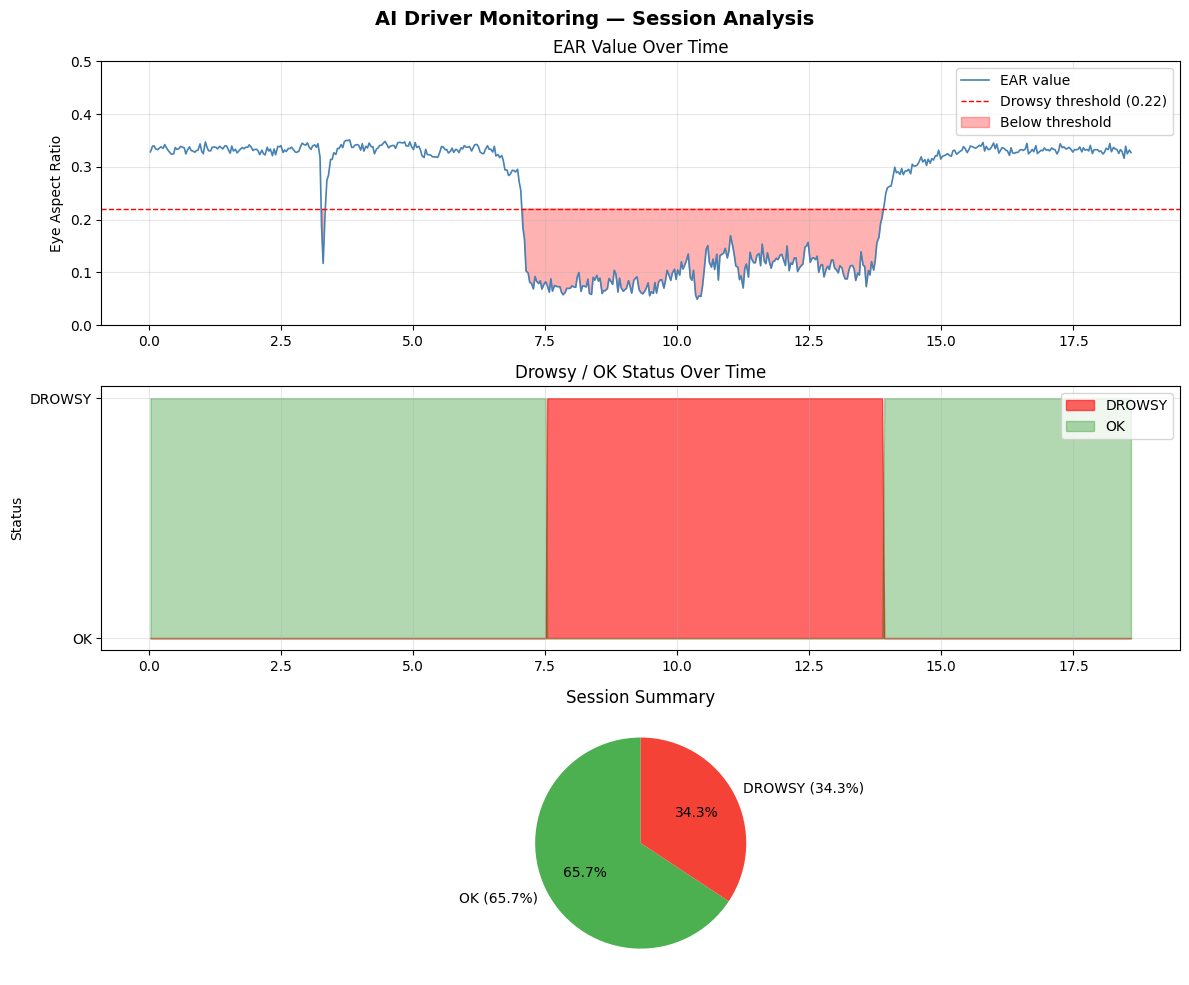

Graphs saved!


In [ ]:
import matplotlib.pyplot as plt
import csv

timestamps = []
ears = []
drowsy_flags = []

# Read the CSV back in
with open('/content/drowsiness_log.csv', 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['ear'] != '':  # only rows where face was detected
            timestamps.append(float(row['timestamp']))
            ears.append(float(row['ear']))
            drowsy_flags.append(int(row['drowsy']))

# ── Graph 1: EAR over time ──
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('AI Driver Monitoring — Session Analysis', fontsize=14, fontweight='bold')

axes[0].plot(timestamps, ears, color='steelblue', linewidth=1.2, label='EAR value')
axes[0].axhline(y=0.22, color='red', linestyle='--', linewidth=1, label='Drowsy threshold (0.22)')
axes[0].fill_between(timestamps, ears, 0.22,
                     where=[e < 0.22 for e in ears],
                     color='red', alpha=0.3, label='Below threshold')
axes[0].set_ylabel('Eye Aspect Ratio')
axes[0].set_title('EAR Value Over Time')
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 0.5)
axes[0].grid(True, alpha=0.3)

# ── Graph 2: Drowsy status over time ──
axes[1].fill_between(timestamps, drowsy_flags,
                     color='red', alpha=0.6, label='DROWSY')
axes[1].fill_between(timestamps, [1 - d for d in drowsy_flags],
                     color='green', alpha=0.3, label='OK')
axes[1].set_ylabel('Status')
axes[1].set_title('Drowsy / OK Status Over Time')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['OK', 'DROWSY'])
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# ── Graph 3: Summary pie chart ──
total = len(drowsy_flags)
drowsy_count = sum(drowsy_flags)
ok_count = total - drowsy_count
drowsy_pct = round(drowsy_count / total * 100, 1)
ok_pct = round(ok_count / total * 100, 1)

axes[2].pie(
    [ok_count, drowsy_count],
    labels=[f'OK ({ok_pct}%)', f'DROWSY ({drowsy_pct}%)'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.1f%%',
    startangle=90
)
axes[2].set_title('Session Summary')

plt.tight_layout()
plt.savefig('/content/drowsiness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphs saved!")

In [ ]:
from google.colab import files
files.download('/content/drowsiness_log.csv')
files.download('/content/drowsiness_analysis.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
size_mb = os.path.getsize('/content/drowsiness_output_h264.mp4') / (1024 * 1024)
print(f"File size: {round(size_mb, 1)} MB")

File size: 3.1 MB
